
Variance Inflation Factor (VIF):
       Variable          VIF
0    EX_AVG_USD   311.954784
1       EXI_IDX  1950.156324
2       IMI_IDX  5952.578612
3            M2  1192.237846
4        policy    18.681288
5   oilwtiprice   135.297997
6  unemployment    55.032171
Removing high VIF columns: ['IMI_IDX', 'M2']

OLS Model Summary (HC3):
                            OLS Regression Results                            
Dep. Variable:                CPI_IDX   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     557.7
Date:                Mon, 29 Sep 2025   Prob (F-statistic):           2.30e-72
Time:                        21:46:58   Log-Likelihood:                 369.43
No. Observations:                 108   AIC:                            -726.9
Df Residuals:                     102   BIC:                            -710.8
Df Model:                      

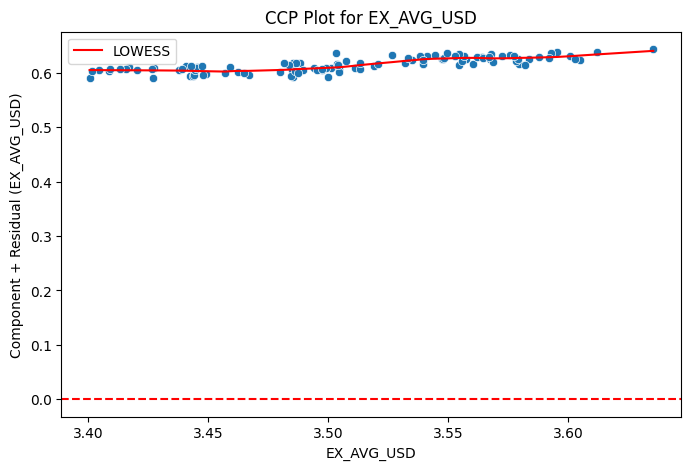

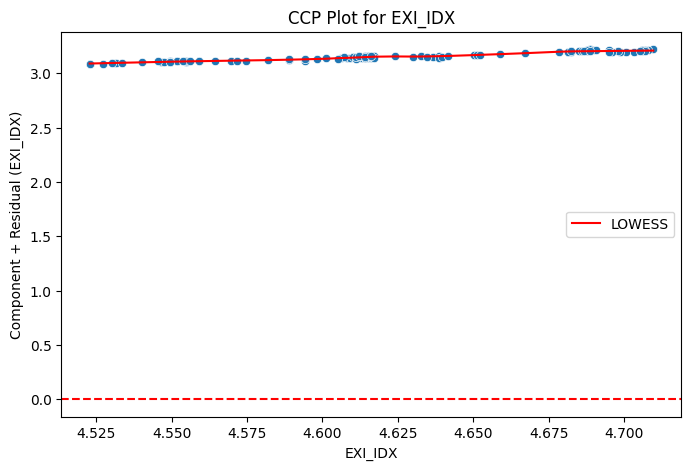

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


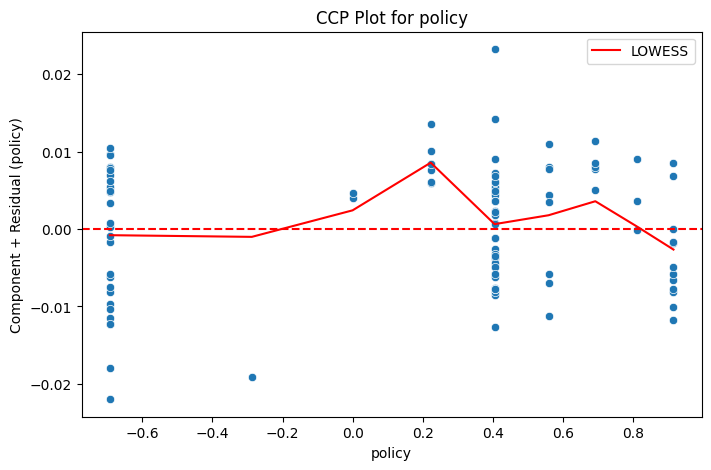

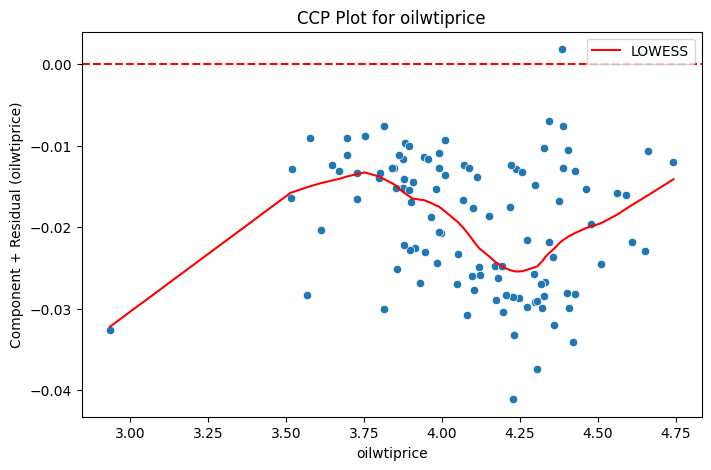

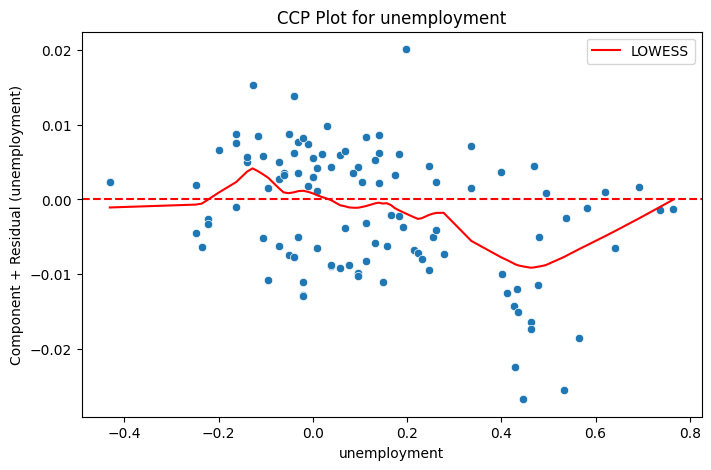


Durbin-Watson: 2.085
Breusch-Godfrey Test: LM Stat=0.351, p-value=0.553

Breusch-Pagan Test:
{'LM Stat': np.float64(14.018463240231554), 'LM p-value': np.float64(0.015492559535225431), 'F-Stat': np.float64(3.042902467446609), 'F p-value': np.float64(0.01333305733993341)}

White Test: (np.float64(35.63416237355633), np.float64(0.016975468904364868), np.float64(2.1420135717233415), np.float64(0.008254993343753911))
Goldfeld-Quandt Test (idx=0, const): F-stat=0.840, p-value=0.726
Goldfeld-Quandt Test (idx=1, EX_AVG_USD): F-stat=0.690, p-value=0.898
Goldfeld-Quandt Test (idx=2, EXI_IDX): F-stat=3.898, p-value=0.000
Goldfeld-Quandt Test (idx=3, policy): F-stat=0.665, p-value=0.920
Goldfeld-Quandt Test (idx=4, oilwtiprice): F-stat=2.744, p-value=0.000
Goldfeld-Quandt Test (idx=5, unemployment): F-stat=1.553, p-value=0.065

Shapiro-Wilk: Stat=0.972, p-value=0.021


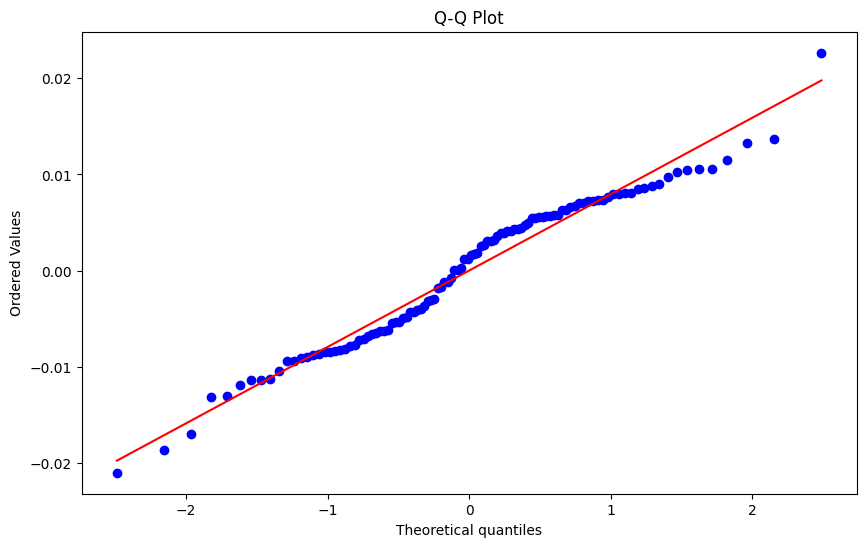


Non-normality detected. Trying Box-Cox transformation.


ValueError: too many values to unpack (expected 2)

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, het_goldfeldquandt, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import power_transform
from sklearn.metrics import mean_squared_error

# โหลดข้อมูล
df = pd.read_csv('https://raw.githubusercontent.com/kimurasaika/car_price_prediction/refs/heads/main/data2.csv')
df = df.drop(columns=['obs', 'month', 'month_num', 'year', 'PPI_IDX', 'GOLD'])
df['M2'] = df['M2'].str.replace(',', '').astype(float)

# แบ่งข้อมูล
X = df.drop(columns=['CPI_IDX'])
y = df['CPI_IDX']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1711)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
X_train_log = X_train.copy()
X_test_log = X_test.copy()
y_train_log = y_train.copy()
y_test_log = y_test.copy()

# Step 1: Impute Missing Values
imputer = IterativeImputer(max_iter=10, random_state=1234)
imputer.fit(X_train)
X_train_log = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_test_log = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
mylist = ['EX_AVG_USD', 'IMI_IDX', 'policy', 'oilwtiprice']
X_train_log[mylist] = X_train[mylist]
X_test_log[mylist] = X_test[mylist]

# Step 2: ตรวจสอบ Multicollinearity
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_log.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_log.values, i) for i in range(X_train_log.shape[1])]
print("\nVariance Inflation Factor (VIF):")
print(vif_data)
# ลบตัวแปรที่มี VIF > 10
high_vif_cols = ['IMI_IDX','M2']
if high_vif_cols:
    print(f"Removing high VIF columns: {high_vif_cols}")
    X_train_log = X_train_log.drop(columns=high_vif_cols)
    X_test_log = X_test_log.drop(columns=high_vif_cols)

# Step 3: Log Transformation เพื่อแก้ non-linearity และ skewness
for col in X_train_log.columns:
    if (X_train_log[col] > 0).all():
        X_train_log[col] = np.log(X_train_log[col] + 1e-10)
        X_test_log[col] = np.log(X_test_log[col] + 1e-10)
if (y_train_log > 0).all():
    y_train_log = np.log(y_train_log + 1e-10)
    y_test_log = np.log(y_test_log + 1e-10)

# Step 4: Fit โมเดล OLS ด้วย Robust SE (HC3)
X_train_const = sm.add_constant(X_train_log)
model = sm.OLS(y_train_log, X_train_const).fit(cov_type='HC3')
print("\nOLS Model Summary (HC3):")
print(model.summary())
residuals = model.resid
fitted = model.fittedvalues

# Step 5: Advanced Assumption Checks
# 5.1 Linearity: Component-Plus-Residual (CCP) Plots
for col in X_train_log.columns:
    component = model.params[col] * X_train_log[col]
    ccp = component + residuals
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=X_train_log[col], y=ccp)
    plt.axhline(y=0, color='r', linestyle='--')
    lowess = sm.nonparametric.lowess(ccp, X_train_log[col], frac=0.3)
    plt.plot(lowess[:, 0], lowess[:, 1], color='red', label='LOWESS')
    plt.xlabel(col)
    plt.ylabel(f'Component + Residual ({col})')
    plt.title(f'CCP Plot for {col}')
    plt.legend()
    plt.show()
# ถ้า LOWESS ไม่เป็นเส้นตรง: เพิ่ม quadratic terms
# Note: The original code had a bug here checking for non-linearity and adding quadratic terms.
# It was attempting to add quadratic terms for 'M2' and 'SAVINGS' which were not guaranteed to be in the dataframe.
# This section is commented out to prevent errors until a more robust approach is implemented.
# if any([not np.allclose(lowess[:, 1], 0, atol=0.1) for col in X_train_log.columns]):
#     print("Non-linearity detected. Considering adding quadratic terms for relevant variables.")
#     # Add logic here to identify which variables need quadratic terms based on CCP plots

# 5.2 Independence: Durbin-Watson + Breusch-Godfrey
dw = durbin_watson(residuals)
print(f'\nDurbin-Watson: {dw:.3f}')
bg_test = acorr_breusch_godfrey(model, nlags=1)
print(f'Breusch-Godfrey Test: LM Stat={bg_test[0]:.3f}, p-value={bg_test[1]:.3f}')
if dw < 1.5 or dw > 2.5 or bg_test[1] < 0.05:
    print("Autocorrelation detected. Using HAC.")
    maxlags = int(0.75 * len(y_train_log)**(1/3))
    model_hac = sm.OLS(y_train_log, X_train_const).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    print(f"\nHAC Model Summary (maxlags={maxlags}):")
    print(model_hac.summary())
    residuals = model_hac.resid
    fitted = model_hac.fittedvalues

# 5.3 Homoscedasticity: Multiple Tests
labels = ['LM Stat', 'LM p-value', 'F-Stat', 'F p-value']
bp_test = het_breuschpagan(residuals, model.model.exog)
print('\nBreusch-Pagan Test:')
print(dict(zip(labels, bp_test)))
white_test = het_white(residuals, model.model.exog)
print(f'\nWhite Test: {white_test}')
for idx, col in enumerate(['const'] + list(X_train_log.columns), 0):
    gq_fstat, gq_pvalue, _ = het_goldfeldquandt(residuals, model.model.exog, idx=idx)
    print(f'Goldfeld-Quandt Test (idx={idx}, {col}): F-stat={gq_fstat:.3f}, p-value={gq_pvalue:.3f}')
# Note: The original code attempted WLS using 'M2' which was dropped.
# This section is commented out. If heteroskedasticity is detected,
# consider alternative methods like transforming the dependent variable
# or using a different model.
# if bp_test[1] < 0.05 or white_test[1] < 0.05:
#     print("\nHeteroskedasticity detected. Trying WLS with appropriate weights.")
#     # Add logic here to determine appropriate weights for WLS if needed.

# 5.4 Normality: Shapiro-Wilk, Q-Q Plot
shapiro = stats.shapiro(residuals)
print(f'\nShapiro-Wilk: Stat={shapiro.statistic:.3f}, p-value={shapiro.pvalue:.3f}')
plt.figure(figsize=(10, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()
if shapiro.pvalue < 0.05:
    print("\nNon-normality detected. Trying Box-Cox transformation.")
    y_train_box, lambda_box = power_transform(y_train.values.reshape(-1, 1), method='box-cox')
    y_train_box = y_train_box.flatten()
    model_boxcox = sm.OLS(y_train_box, X_train_const).fit(cov_type='HC3')
    print("\nBox-Cox Model Summary:")
    print(model_boxcox.summary())
    residuals = model_boxcox.resid
    shapiro_boxcox = stats.shapiro(residuals)
    print(f'\nShapiro-Wilk (Box-Cox): Stat={shapiro_boxcox.statistic:.3f}, p-value={shapiro_boxcox.pvalue:.3f}')

# 5.5 Outliers: Cook's Distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]
plt.figure(figsize=(10, 6))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.title("Cook's Distance")
plt.show()
outliers = np.where(cooks_d > 1)[0]
if len(outliers) > 0:
    print(f"Outliers detected at indices: {outliers}")
    X_train_log = X_train_log.drop(index=outliers).reset_index(drop=True)
    y_train_log = y_train_log.drop(index=outliers).reset_index(drop=True)
    X_train_const = sm.add_constant(X_train_log)
    model = sm.OLS(y_train_log, X_train_const).fit(cov_type='HC3')
    print("\nUpdated Model Summary (after removing outliers):")
    print(model.summary())
    residuals = model.resid
    fitted = model.fittedvalues

# Step 6: Bootstrap SE
def ols_coefficients(indices):
    X_resampled = X_train_log.iloc[indices]
    y_resampled = y_train_log.iloc[indices]
    X_resampled_const = sm.add_constant(X_resampled)
    model = sm.OLS(y_resampled, X_resampled_const).fit()
    return model.params

indices = np.arange(len(y_train_log))
data = (indices,)
rng = np.random.default_rng(42)
res = stats.bootstrap(data, ols_coefficients, n_resamples=1000, confidence_level=0.95,
                      method='BCa', random_state=rng, vectorized=False)
bootstrap_se = res.standard_error
param_names = ['const'] + list(X_train_log.columns)
print("\nBootstrap Standard Errors:")
for name, se in zip(param_names, bootstrap_se):
    print(f"{name}: {se:.4f}")

# Step 7: Evaluate on Test Set
X_test_const = sm.add_constant(X_test_log)
y_pred_test = model.predict(X_test_const)
print(f'\nTest MSE: {mean_squared_error(y_test_log, y_pred_test):.4f}')